In [80]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from sklearn.utils import shuffle
from keras.layers import LSTM, GRU, Dropout, Dense, Input
from imblearn.over_sampling import RandomOverSampler
import random
import os

In [70]:
# =============================
# 1. Charger les données
# =============================
df = pd.read_csv("C:\\Users\\sarrj\\Documents\\Mes doc\\Doc\\Articles\\smart_manufacturing_data.csv")#, parse_dates=['timestamp'], index_col='timestamp')
#df = pd.read_csv("C:\\Users\\sarrj\\Documents\\Mes doc\\Doc\\Articles\\smart_manufacturing_data.csv")

# =============================
# 2. Appliquer les seuils ISO
# =============================
def iso_state(v):
    if pd.isna(v):
        return np.nan
    if v < 2.8:
        return 1 #--'OK'
    elif v < 7.1:
        return 2 #--'Attention'
    elif v < 11.2:
        return 3 #--'Alerte'
    else:
        return 0 #'Critique'

df['State_ISO'] = df['vibration'].apply(iso_state)
df = df[['timestamp','machine_id','pressure', 'temperature', 'vibration', 'humidity','energy_consumption','machine_status','anomaly_flag','predicted_remaining_life','downtime_risk','maintenance_required','State_ISO']]
#print(df.columns)

df_g = df.groupby(['timestamp','machine_id','machine_status','anomaly_flag','predicted_remaining_life','downtime_risk','maintenance_required','State_ISO'])
df_g_m = df_g[['pressure', 'temperature', 'vibration', 'humidity','energy_consumption']].mean()
df = df_g_m.reset_index()

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')

#df = df[df['vibration'] <= 7]
print(df.head())


                     machine_id  machine_status  anomaly_flag  \
timestamp                                                       
2025-01-01 00:00:00          39               1             0   
2025-01-01 00:01:00          29               1             0   
2025-01-01 00:02:00          15               1             1   
2025-01-01 00:03:00          43               1             1   
2025-01-01 00:04:00           8               2             0   

                     predicted_remaining_life  downtime_risk  \
timestamp                                                      
2025-01-01 00:00:00                       106            0.0   
2025-01-01 00:01:00                       320            0.0   
2025-01-01 00:02:00                        19            1.0   
2025-01-01 00:03:00                        10            1.0   
2025-01-01 00:04:00                        65            0.0   

                     maintenance_required  State_ISO  pressure  temperature  \
timestamp       

In [71]:

df = df.resample('5min').mean()
#print(df.head())
print(df.shape)

print(df['State_ISO'].unique())
# Utiliser le timpestamp comme index
##df = df.sort_values('timestamp').reset_index(drop=True)
##df['timestamp'] = pd.to_datetime(df['timestamp'])
##df = df.set_index('timestamp')

#print(df.head())
# ===========================================
# 3. Définir la colonne cible : panne
# (Critique = panne, le reste = normal)
# ===========================================
df['panne'] = (df['State_ISO'] == 0).astype(int) #-- Critique
#print(df.head())
# =============================
# 4. Normaliser les variables d'entrée
# =============================

features = ['pressure', 'temperature', 'vibration', 'humidity','energy_consumption']
df[features] = df[features].astype(np.float32)



(20000, 12)
[0.  0.6 0.4 0.2 1.  0.8]


In [72]:
scaler = MinMaxScaler()

df[features] = scaler.fit_transform(df[features])
df.dropna(inplace=True)

In [73]:
# =============================
# 5. Créer les séquences temporelles
# =============================
def create_sequences(df, features, target='panne', time_steps=20, max_samples = None):
    X, y = [], []
    for i in range(max_samples - time_steps):
        X.append(df[features].iloc[i:i + time_steps].values)
        y.append(df[target].iloc[i + time_steps])
    return np.array(X), np.array(y)

time_steps = 5
X, y = create_sequences(df, features, target='panne', time_steps=5, max_samples=len(df))##, max_samples=15000)

#X, y = create_sequences(df, features, target='panne', time_steps=time_steps)

# 1. Aplatir X (nécessaire pour RandomOverSampler)
X_flat = X.reshape((X.shape[0], -1))
print(f"Avant RandomOverSampler : {np.bincount(y)}")

# 2. Appliquer RandomOverSampler
ros = RandomOverSampler(sampling_strategy=0.5, random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_flat, y)
print(f"Après RandomOverSampler : {np.bincount(y_resampled)}")

# 3. Reformater pour LSTM
X_resampled = X_resampled.reshape((X_resampled.shape[0], time_steps, len(features)))

# 4. Mélanger les données (pour casser l'ordre temporel global)
X_resampled, y_resampled = shuffle(X_resampled, y_resampled, random_state=42)

# =============================
# 8. Split Train/Test
# =============================
split = int(0.8 * len(X_resampled))
X_train, X_test = X_resampled[:split], X_resampled[split:]
y_train, y_test = y_resampled[:split], y_resampled[split:]

Avant RandomOverSampler : [  470 19525]
Après RandomOverSampler : [ 9762 19525]


In [74]:
print(df.head())
print('\n', df['panne'].value_counts())

# Sauvegarder un CSV pré-traité
DEST_CSV = 'resume_c1.csv'
df.to_csv(DEST_CSV, index=True)
print('Fichier pré-traité sauvegardé :', DEST_CSV)


                     machine_id  machine_status  anomaly_flag  \
timestamp                                                       
2025-01-01 00:00:00        26.8             1.2           0.4   
2025-01-01 00:05:00        22.6             0.8           0.2   
2025-01-01 00:10:00        27.0             1.2           0.0   
2025-01-01 00:15:00        19.0             1.0           0.6   
2025-01-01 00:20:00        24.8             1.2           0.2   

                     predicted_remaining_life  downtime_risk  \
timestamp                                                      
2025-01-01 00:00:00                     104.0            0.4   
2025-01-01 00:05:00                     243.0            0.2   
2025-01-01 00:10:00                     207.2            0.0   
2025-01-01 00:15:00                      58.6            0.6   
2025-01-01 00:20:00                     283.0            0.2   

                     maintenance_required  State_ISO  pressure  temperature  \
timestamp       

In [68]:
# =============================
# 7. Modèle 2  LSTM
# =============================
# Fixer les seeds pour la reproductibilité
seed_value = 42

os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)


model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entraînement avec early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=65,
    batch_size=64,
    callbacks=[early_stop],
    class_weight={0: 1, 1: 3}  # Ajustable
)

y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.7).astype(int)

print(classification_report(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_proba)))

Epoch 1/65
275/275 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6690 - loss: 0.9878 - val_accuracy: 0.6574 - val_loss: 0.7931
Epoch 2/65
275/275 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6690 - loss: 0.9643 - val_accuracy: 0.6574 - val_loss: 0.7926
Epoch 3/65
275/275 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6690 - loss: 0.9622 - val_accuracy: 0.6574 - val_loss: 0.7981
Epoch 4/65
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6690 - loss: 0.9610 - val_accuracy: 0.6574 - val_loss: 0.7909
Epoch 5/65
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6690 - loss: 0.9605 - val_accuracy: 0.6574 - val_loss: 0.7882
Epoch 6/65
275/275 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6690 - loss: 0.9593 - val_accuracy: 0.6574 - val_loss: 0.7871
Epoch 7/65
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6690 - loss: 0.9609 - val_accuracy: 0.6574 - val_loss: 0.7830
Epoch 8/65
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6690 - loss: 0.9586 - val_accu

In [ ]:
# 1. Prédictions brutes (probabilités) et classes
y_proba = model.predict(X_test).flatten()
y_pred = (y_proba > 0.5).astype(int)

# 2. Classification Metrics
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# 3. Erreurs (sur probabilités ou classes)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # ou y_proba
msae = mean_absolute_error(y_test, y_pred)

# 4. Affichage
print("\n📈 Métriques de performance :")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"F1-score     : {f1:.4f}")
print(f"RMSE         : {rmse:.4f}")
print(f"MSAE (MAE)   : {msae:.4f}")

In [ ]:
# =============================
# 7. Modèle GRU-LSTM
# =============================
# Fixer les seeds pour la reproductibilité
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# Modèle GRU-LSTM
model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(GRU(64, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entraînement
model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    class_weight={0: 2, 1: 1}
)

# Prédiction et métriques
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.3).astype(int)

print(classification_report(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_proba)))

In [76]:
# 1. Prédictions brutes (probabilités) et classes
y_proba = model.predict(X_test).flatten()
y_pred = (y_proba > 0.5).astype(int)

# 2. Classification Metrics
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# 3. Erreurs (sur probabilités ou classes)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # ou y_proba
msae = mean_absolute_error(y_test, y_pred)

# 4. Affichage
print("\n📈 Métriques de performance :")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"F1-score     : {f1:.4f}")
print(f"RMSE         : {rmse:.4f}")
print(f"MSAE (MAE)   : {msae:.4f}")

184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step 

📈 Métriques de performance :
Recall       : 1.0000
Precision    : 0.6540
F1-score     : 0.7908
RMSE         : 0.5882
MSAE (MAE)   : 0.3460


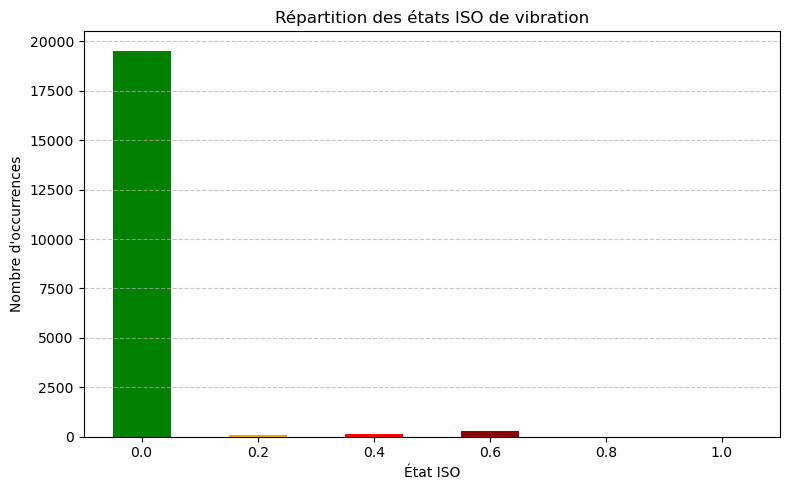

In [47]:
# Compter les occurrences par état
state_counts = df['State_ISO'].value_counts().sort_index()

# Affichage
plt.figure(figsize=(8, 5))
state_counts.plot(kind='bar', color=['green', 'orange', 'red', 'darkred'])
plt.title("Répartition des états ISO de vibration")
plt.xlabel("État ISO")
plt.ylabel("Nombre d'occurrences")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

733/733 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


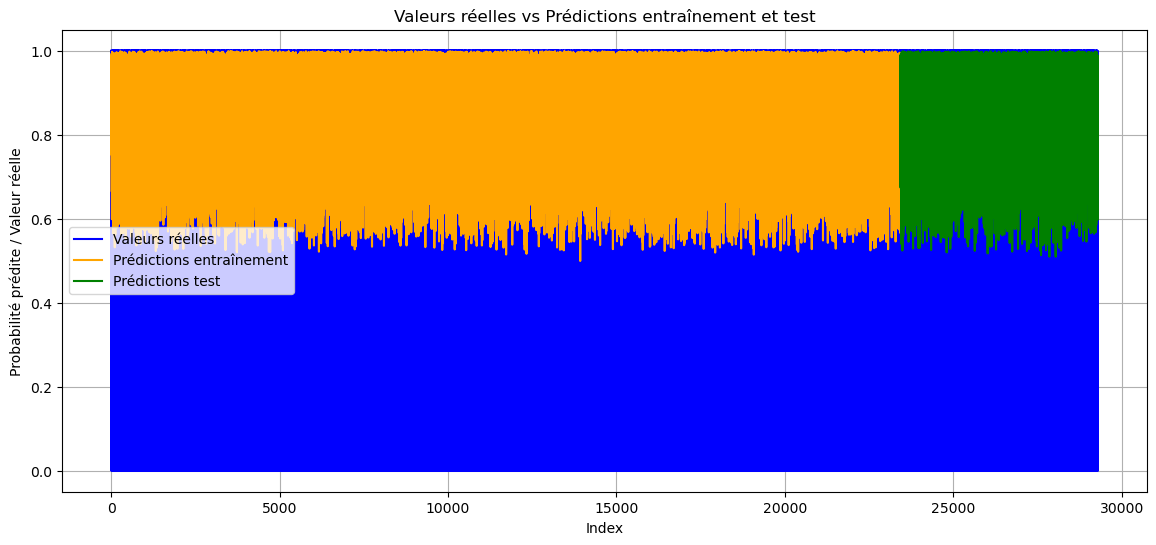

In [48]:
# Prédictions sur train (en probabilités)
y_train_pred_proba = model.predict(X_train)

# On peut aussi transformer en labels binaires si besoin
# y_train_pred = (y_train_pred_proba > 0.7).astype(int)

# Préparer un vecteur complet pour la vraie valeur + prédictions pour la visualisation
# On concatène train + test

y_true = np.concatenate([y_train, y_test])
y_pred_proba_full = np.concatenate([y_train_pred_proba, y_pred_proba])

plt.figure(figsize=(14,6))
plt.plot(y_true, label='Valeurs réelles', color='blue')
plt.plot(np.arange(len(y_train_pred_proba)), y_train_pred_proba, label='Prédictions entraînement', color='orange')
plt.plot(np.arange(len(y_train_pred_proba), len(y_train_pred_proba)+len(y_pred_proba)), y_pred_proba, label='Prédictions test', color='green')
plt.title('Valeurs réelles vs Prédictions entraînement et test')
plt.xlabel('Index')
plt.ylabel('Probabilité prédite / Valeur réelle')
plt.legend()
plt.grid()
plt.show()